Parametry sigmoid transformace:
  k_neg (záporná větev): 0.261
  k_pos (kladná větev): 0.261


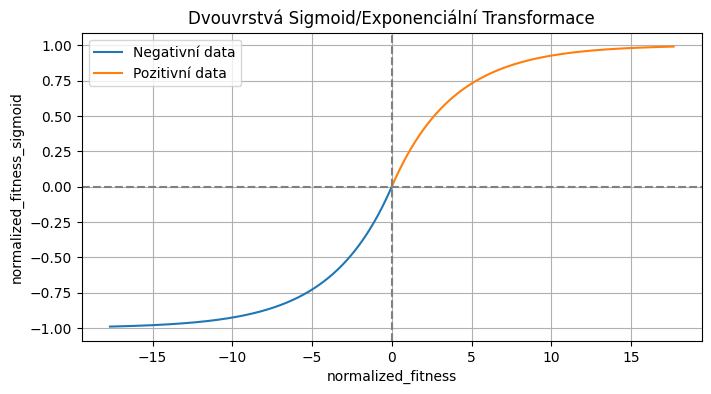

In [1]:
# Jupyter buňka: výpočet parametrů sigmoid/exponenciální transformace

import numpy as np

def compute_sigmoid_params(min_neg, max_neg, min_pos, max_pos, target_saturation=0.9):
    """
    min_neg, max_neg: rozsah záporných hodnot (např. -5.5, 0)
    min_pos, max_pos: rozsah kladných hodnot (např. 0, 2.3)
    target_saturation: hodnota sigmoid/exponenciální transformace pro min/max (0 < target_saturation < 1)

    Vrací: k_neg, k_pos
    """
    # Záporná větev: f(-min_neg) = target_saturation
    k_neg = np.log(1/(1-target_saturation)) / (-min_neg)

    # Kladná větev: f(max_pos) = target_saturation
    k_pos = -np.log(1-target_saturation) / max_pos

    return k_neg, k_pos

# --- Zde zadáš minima/maxima ---
min_neg = -17.67
max_neg = 0
min_pos = 0
max_pos = 17.67
target_saturation = 0.99

k_neg, k_pos = compute_sigmoid_params(min_neg, max_neg, min_pos, max_pos, target_saturation)

print(f"Parametry sigmoid transformace:")
print(f"  k_neg (záporná větev): {k_neg:.3f}")
print(f"  k_pos (kladná větev): {k_pos:.3f}")

# --- volitelně: vizualizace ---
import matplotlib.pyplot as plt

x_neg = np.linspace(min_neg, max_neg, 500)
x_pos = np.linspace(min_pos, max_pos, 500)

y_neg = -1 + np.exp(k_neg * x_neg)
y_pos = 1 - np.exp(-k_pos * x_pos)

plt.figure(figsize=(8,4))
plt.plot(x_neg, y_neg, label="Negativní data")
plt.plot(x_pos, y_pos, label="Pozitivní data")
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel("normalized_fitness")
plt.ylabel("normalized_fitness_sigmoid")
plt.title("Dvouvrstvá Sigmoid/Exponenciální Transformace")
plt.grid(True)
plt.legend()
plt.show()
